In [1]:
from __future__ import annotations

from pathlib import Path
from IPython.display import display
import hashlib
import json
import platform
import random
import sys
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("seaborn-v0_8-whitegrid")

PROJECT_ROOT = Path(r"D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver")
DATASET_ROOT = Path(
    r"D:\DATA SCIENCE AND ANALYTICS\Dataset\Liver\02_staging"
    r"\build_corrected_20260713_214847_v2"
)
MANIFEST_PATH = DATASET_ROOT / "manifests" / "slice_manifest.csv"
CHECKPOINT_PATH = (
    PROJECT_ROOT / "Practice" / "multitask_liver_tumor_outputs" / "multitask_best.pth"
)
OUTPUT_DIR = PROJECT_ROOT / "mark 1" / "mark_1_outputs"
CACHE_DIR = OUTPUT_DIR / "probability_cache"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RUN_FULL_DIAGNOSTIC = True
REBUILD_CACHE = False
RUN_HU_ANALYSIS = True
SEED = 42
BATCH_SIZE = 16
NUM_WORKERS = 0
ORGAN_Z_CLIP = 3.0
EXPECTED_MANIFEST_SHA256 = (
    "575a6fc391d63dc9bbbbb3317efe4d0f65edd57457ae63c1bfc6c2c615861889"
)
EXPECTED_CHECKPOINT_EPOCH = 8
EXPECTED_VALIDATION_SLICES = 10_685
EXPECTED_VALIDATION_PATIENTS = 13

COARSE_TUMOR_THRESHOLDS = np.array(
    [0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70],
    dtype=np.float32,
)
LIVER_THRESHOLDS = np.array([0.30, 0.40, 0.50, 0.60, 0.70], dtype=np.float32)
LIVER_DILATION_KERNELS = [1, 5, 11, 21, 31]
BOOTSTRAP_ITERATIONS = 1_000

TARGETS = {
    "mean_patient_dice": 0.406915,
    "volume_104_dice": 0.50,
    "volume_116_dice": 0.05,
    "q1_detected_pct": 45.0,
    "positive_predicted_empty_pct": 20.0,
    "empty_slice_false_positive_pct": 15.0,
}

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Python {sys.version.split()[0]} | PyTorch {torch.__version__}")
print(f"OS: {platform.platform()} | CUDA available: {torch.cuda.is_available()}")
print(f"Mode: {'FULL DIAGNOSTIC' if RUN_FULL_DIAGNOSTIC else 'PREFLIGHT ONLY'}")
print(f"Outputs: {OUTPUT_DIR}")

Python 3.11.15 | PyTorch 2.6.0+cu124
OS: Windows-10-10.0.26200-SP0 | CUDA available: True
Mode: FULL DIAGNOSTIC
Outputs: D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver\mark 1\mark_1_outputs


In [2]:
from src.framework.data.manifest_dataset import VerifiedManifestDataset

def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        while chunk := handle.read(chunk_size):
            digest.update(chunk)
    return digest.hexdigest()

manifest_hash = sha256_file(MANIFEST_PATH)
checkpoint_hash = sha256_file(CHECKPOINT_PATH)
assert manifest_hash == EXPECTED_MANIFEST_SHA256

manifest = pd.read_csv(MANIFEST_PATH)
required_columns = {
    "sample_id", "volume_id", "slice_index", "image_path",
    "organ_mask_path", "tumor_mask_path", "source_volume_path",
    "source_segmentation_path", "transform_applied", "split",
    "tumor_pixels", "organ_pixels", "verification_status",
    "manual_spatial_status",
}
assert not (required_columns - set(manifest.columns))
assert len(manifest) == 58_638
assert manifest["sample_id"].is_unique
assert not manifest[["volume_id", "slice_index"]].duplicated().any()
assert manifest["verification_status"].eq("verified").all()
assert manifest["manual_spatial_status"].eq("approved").all()

split_patients = {
    split: set(manifest.loc[manifest["split"].eq(split), "volume_id"].astype(int))
    for split in ("train", "val", "test")
}
assert split_patients["train"].isdisjoint(split_patients["val"])
assert split_patients["train"].isdisjoint(split_patients["test"])
assert split_patients["val"].isdisjoint(split_patients["test"])

validation_manifest = (
    manifest.loc[manifest["split"].eq("val")]
    .sort_values(["volume_id", "slice_index"])
    .reset_index(drop=True)
)
assert len(validation_manifest) == EXPECTED_VALIDATION_SLICES
assert validation_manifest["volume_id"].nunique() == EXPECTED_VALIDATION_PATIENTS

try:
    VerifiedManifestDataset(MANIFEST_PATH, split="test", root_dir=DATASET_ROOT)
except PermissionError as error:
    test_lock_message = str(error)
else:
    raise AssertionError("STOP: the test dataset opened without explicit authorization.")

provenance = {
    "manifest_path": str(MANIFEST_PATH),
    "manifest_sha256": manifest_hash,
    "checkpoint_path": str(CHECKPOINT_PATH),
    "checkpoint_sha256": checkpoint_hash,
    "validation_slices": int(len(validation_manifest)),
    "validation_patients": int(validation_manifest["volume_id"].nunique()),
    "random_seed": SEED,
    "python": sys.version,
    "pytorch": torch.__version__,
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "cuda_available": bool(torch.cuda.is_available()),
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    "test_images_accessed": False,
    "test_lock_message": test_lock_message,
    "run_full_diagnostic": RUN_FULL_DIAGNOSTIC,
}
(OUTPUT_DIR / "mark_1_provenance.json").write_text(
    json.dumps(provenance, indent=2), encoding="utf-8"
)
display(pd.DataFrame([{
    "manifest": manifest_hash,
    "checkpoint": checkpoint_hash,
    "validation_slices": len(validation_manifest),
    "validation_patients": validation_manifest["volume_id"].nunique(),
    "test_locked": True,
}]))
print("PASS: provenance, manifest geometry, patient isolation, and test lock verified.")

,manifest,checkpoint,validation_slices,validation_patients,test_locked
0,575a6fc391d63dc9bbbbb3317efe4d0f65edd57457ae63...,9c4160bbd68891f9dc4e5f04ceca4391f38c5869b3f81c...,10685,13,True


PASS: provenance, manifest geometry, patient isolation, and test lock verified.


In [3]:
from src.framework.models.mobilenetv2_unet import MobileNetV2UNet

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=False)
required_checkpoint_keys = {
    "epoch", "model_state", "manifest_sha256", "source_checkpoint_sha256",
    "configuration",
}
assert not (required_checkpoint_keys - set(checkpoint))
assert int(checkpoint["epoch"]) == EXPECTED_CHECKPOINT_EPOCH
assert checkpoint["manifest_sha256"] == manifest_hash

model = MobileNetV2UNet(in_channels=1, out_channels=2, pretrained=False)
model.load_state_dict(checkpoint["model_state"], strict=True)
model.to(device).eval()

with torch.inference_mode():
    probe = torch.zeros((1, 1, 256, 256), dtype=torch.float32, device=device)
    probe_logits = model(probe)
    probe_probabilities = torch.sigmoid(probe_logits)
assert tuple(probe_logits.shape) == (1, 2, 256, 256)
assert torch.isfinite(probe_probabilities).all()
assert float(probe_probabilities.min()) >= 0.0
assert float(probe_probabilities.max()) <= 1.0

provenance.update({
    "checkpoint_epoch": int(checkpoint["epoch"]),
    "parent_checkpoint_sha256": checkpoint["source_checkpoint_sha256"],
    "checkpoint_configuration": checkpoint["configuration"],
    "model_input_shape": [1, 1, 256, 256],
    "model_output_shape": list(probe_logits.shape),
    "strict_checkpoint_load": True,
})
(OUTPUT_DIR / "mark_1_provenance.json").write_text(
    json.dumps(provenance, indent=2), encoding="utf-8"
)
print(
    "PASS: strict epoch-8 checkpoint load; "
    f"checkpoint={checkpoint_hash[:12]}..., "
    f"parent={checkpoint['source_checkpoint_sha256'][:12]}..."
)

PASS: strict epoch-8 checkpoint load; checkpoint=9c4160bbd688..., parent=5f18223c0f61...


In [4]:
def image_robust_normalize(image: np.ndarray) -> np.ndarray:
    image = np.asarray(image, dtype=np.float32)
    reference = image[image > 0]
    if reference.size < 32:
        reference = image.reshape(-1)
    center = float(np.median(reference))
    q25, q75 = np.percentile(reference, [25, 75])
    robust_sigma = float((q75 - q25) / 1.349)
    if not np.isfinite(robust_sigma) or robust_sigma < 1e-3:
        robust_sigma = max(float(np.std(reference)), 1e-3)
    normalized = np.clip(
        (image - center) / robust_sigma, -ORGAN_Z_CLIP, ORGAN_Z_CLIP
    )
    return ((normalized + ORGAN_Z_CLIP) / (2 * ORGAN_Z_CLIP)).astype(np.float32)

class Mark1ValidationDataset(Dataset):
    def __init__(self, base_dataset):
        self.base = base_dataset
        self.rows = base_dataset.rows

    def __len__(self):
        return len(self.base)

    def __getitem__(self, index):
        sample = self.base[index]
        image = image_robust_normalize(sample["image"][0].numpy())
        with Image.open(self.rows[index]["organ_mask_path"]) as handle:
            organ = (np.asarray(handle.convert("L"), dtype=np.uint8) > 0).astype(np.uint8)
        return {
            "image": torch.from_numpy(image[None]).float(),
            "tumor_mask": sample["mask"].to(torch.uint8),
            "organ_mask": torch.from_numpy(organ[None]),
            "sample_id": sample["sample_id"],
            "volume_id": int(sample["volume_id"]),
            "slice_index": int(sample["slice_index"]),
        }

validation_dataset = None
validation_loader = None
if RUN_FULL_DIAGNOSTIC:
    validation_base = VerifiedManifestDataset(
        MANIFEST_PATH, split="val", root_dir=DATASET_ROOT,
        target="tumor", transform=None, validate_paths=True,
    )
    validation_dataset = Mark1ValidationDataset(validation_base)
    validation_loader = DataLoader(
        validation_dataset, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(),
    )
    assert len(validation_dataset) == EXPECTED_VALIDATION_SLICES
    print(f"READY: validation loader contains {len(validation_dataset):,} slices.")
else:
    print("SKIP: full loader construction requires RUN_FULL_DIAGNOSTIC=True.")

READY: validation loader contains 10,685 slices.


In [5]:
def write_status(**updates):
    status_path = OUTPUT_DIR / "mark_1_status.json"
    status = json.loads(status_path.read_text()) if status_path.is_file() else {}
    status.update(updates)
    status["updated_at"] = pd.Timestamp.now(tz="UTC").isoformat()
    status["test_images_accessed"] = False
    status_path.write_text(json.dumps(status, indent=2), encoding="utf-8")
    return status

def save_volume_cache(volume_id, bucket):
    order = np.argsort(bucket["slice_index"])
    payload = {key: np.asarray(value)[order] for key, value in bucket.items()}
    np.savez_compressed(CACHE_DIR / f"volume_{volume_id}.npz", **payload)

def cache_validation_probabilities():
    current_volume = None
    bucket = None
    processed = []
    model.eval()
    write_status(last_completed_step=2, cache_complete=False, volumes_processed=[])
    with torch.inference_mode():
        for batch in validation_loader:
            images = batch["image"].to(device, non_blocking=True)
            probabilities = torch.sigmoid(model(images)).cpu().numpy()
            for index, sample_id in enumerate(batch["sample_id"]):
                volume_id = int(batch["volume_id"][index])
                if current_volume is None:
                    current_volume = volume_id
                    bucket = {
                    "sample_id": [], "slice_index": [],
                    "tumor_truth": [], "organ_truth": [],
                    "liver_probability": [], "tumor_probability": [],
                    }
                elif volume_id != current_volume:
                    save_volume_cache(current_volume, bucket)
                    processed.append(current_volume)
                    write_status(
                        last_completed_step=4,
                        cache_complete=False,
                        volumes_processed=processed,
                        next_resumable_action=f"continue cache from volume {volume_id}",
                    )
                    current_volume = volume_id
                    bucket = {
                        "sample_id": [], "slice_index": [],
                        "tumor_truth": [], "organ_truth": [],
                        "liver_probability": [], "tumor_probability": [],
                    }
                bucket["sample_id"].append(str(sample_id))
                bucket["slice_index"].append(int(batch["slice_index"][index]))
                bucket["tumor_truth"].append(
                    batch["tumor_mask"][index, 0].numpy().astype(np.uint8)
                )
                bucket["organ_truth"].append(
                    batch["organ_mask"][index, 0].numpy().astype(np.uint8)
                )
                bucket["liver_probability"].append(probabilities[index, 0].astype(np.float16))
                bucket["tumor_probability"].append(probabilities[index, 1].astype(np.float16))

    if current_volume is not None:
        save_volume_cache(current_volume, bucket)
        processed.append(current_volume)
    write_status(
        last_completed_step=4,
        cache_complete=True,
        volumes_processed=processed,
        next_resumable_action="run localization and calibration analyses",
    )

if RUN_FULL_DIAGNOSTIC:
    existing = sorted(CACHE_DIR.glob("volume_*.npz"))
    if REBUILD_CACHE or len(existing) != EXPECTED_VALIDATION_PATIENTS:
        cache_validation_probabilities()
    else:
        print(f"REUSE: found {len(existing)} patient caches.")
else:
    write_status(
        last_completed_step=2,
        cache_complete=False,
        volumes_processed=[],
        next_resumable_action="set RUN_FULL_DIAGNOSTIC=True and rerun from the top",
    )
    print("SKIP: inference disabled in preflight mode.")

In [6]:
def load_cache():
    cached = {}
    coverage = []
    for path in sorted(CACHE_DIR.glob("volume_*.npz")):
        volume_id = int(path.stem.split("_")[-1])
        with np.load(path, allow_pickle=False) as payload:
            item = {key: payload[key] for key in payload.files}
        expected = validation_manifest.loc[
            validation_manifest["volume_id"].eq(volume_id)
        ].sort_values("slice_index")
        assert len(item["sample_id"]) == len(expected)
        assert item["sample_id"].astype(str).tolist() == expected["sample_id"].astype(str).tolist()
        assert np.array_equal(item["slice_index"], expected["slice_index"].to_numpy())
        for key in ("tumor_truth", "organ_truth",
                    "liver_probability", "tumor_probability"):
            assert item[key].shape[1:] == (256, 256)
        for key in ("liver_probability", "tumor_probability"):
            assert np.isfinite(item[key]).all()
            assert float(item[key].min()) >= 0 and float(item[key].max()) <= 1
        cached[volume_id] = item
        coverage.append({
            "volume_id": volume_id,
            "slices": len(item["sample_id"]),
            "tumor_positive_slices": int(item["tumor_truth"].any(axis=(1, 2)).sum()),
            "cache_dtype": str(item["tumor_probability"].dtype),
            "cache_mb": path.stat().st_size / (1024 ** 2),
        })
    coverage_frame = pd.DataFrame(coverage)
    assert len(cached) == EXPECTED_VALIDATION_PATIENTS
    assert int(coverage_frame["slices"].sum()) == EXPECTED_VALIDATION_SLICES
    coverage_frame.to_csv(OUTPUT_DIR / "cache_coverage.csv", index=False)
    return cached, coverage_frame

probability_cache = None
coverage_frame = None
if RUN_FULL_DIAGNOSTIC:
    probability_cache, coverage_frame = load_cache()
    display(coverage_frame)
    print("PASS: complete, ordered, finite validation cache.")
else:
    print("SKIP: cache validation awaits full inference.")

,volume_id,slices,tumor_positive_slices,cache_dtype,cache_mb
0,104,781,122,float16,83.453427
1,105,986,0,float16,105.489108
2,106,771,0,float16,81.110108
3,107,771,71,float16,81.570901
4,108,856,202,float16,91.343683
5,109,756,131,float16,80.252860
6,110,816,130,float16,85.879256
7,111,761,92,float16,80.794309
8,112,751,26,float16,79.941479
9,113,836,135,float16,88.831850


PASS: complete, ordered, finite validation cache.


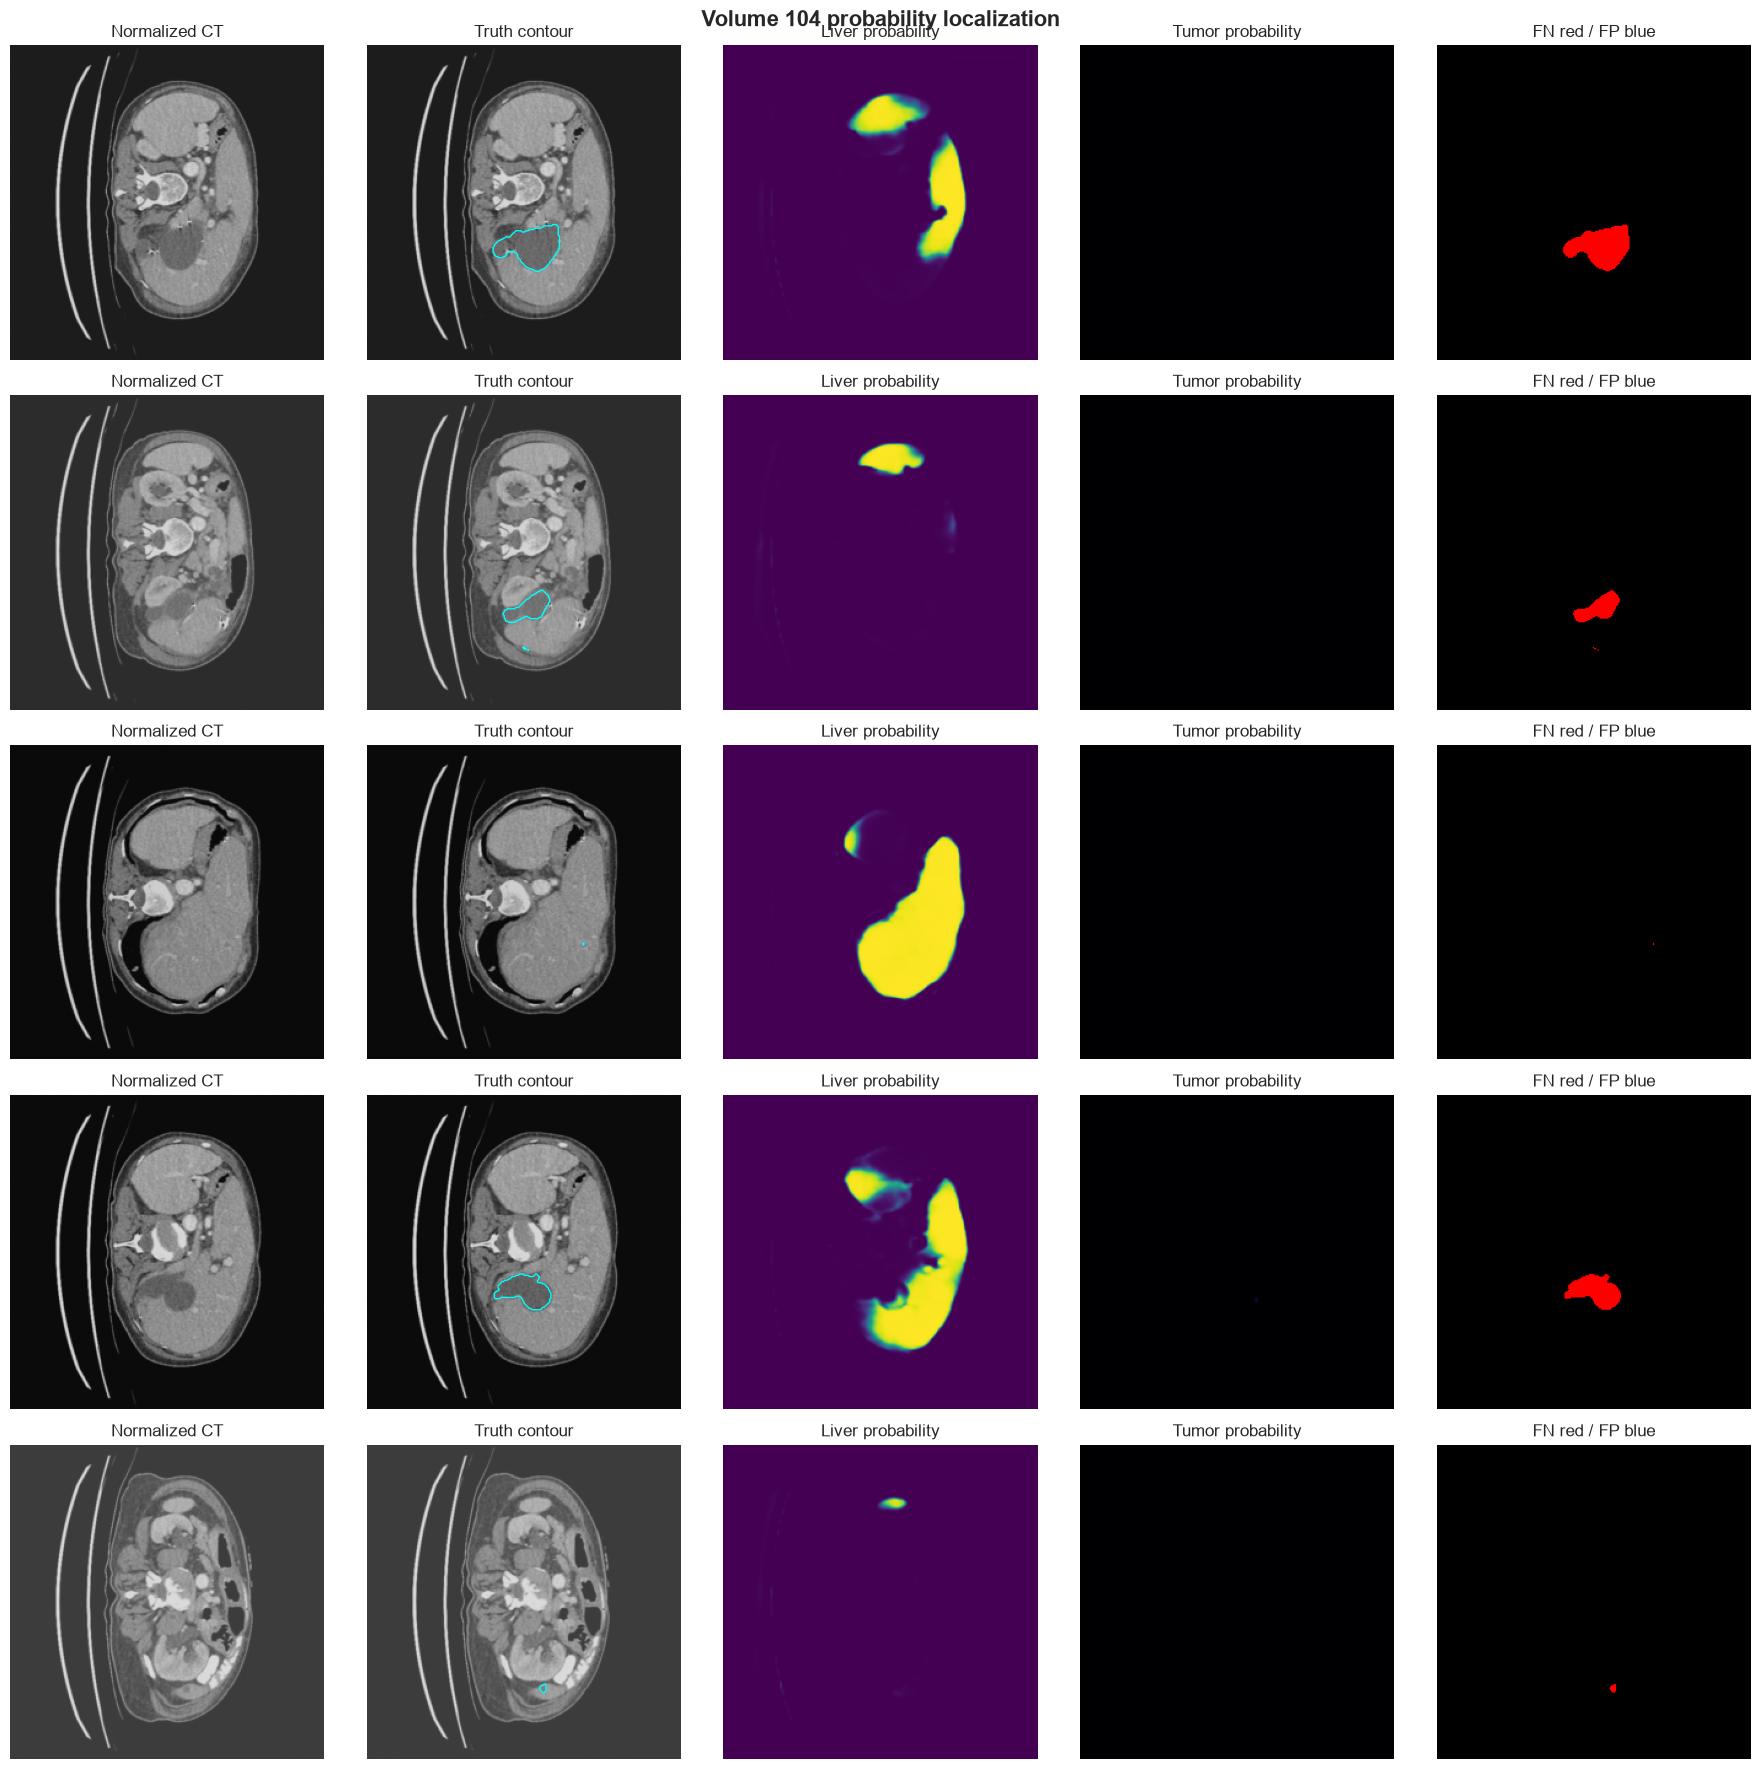

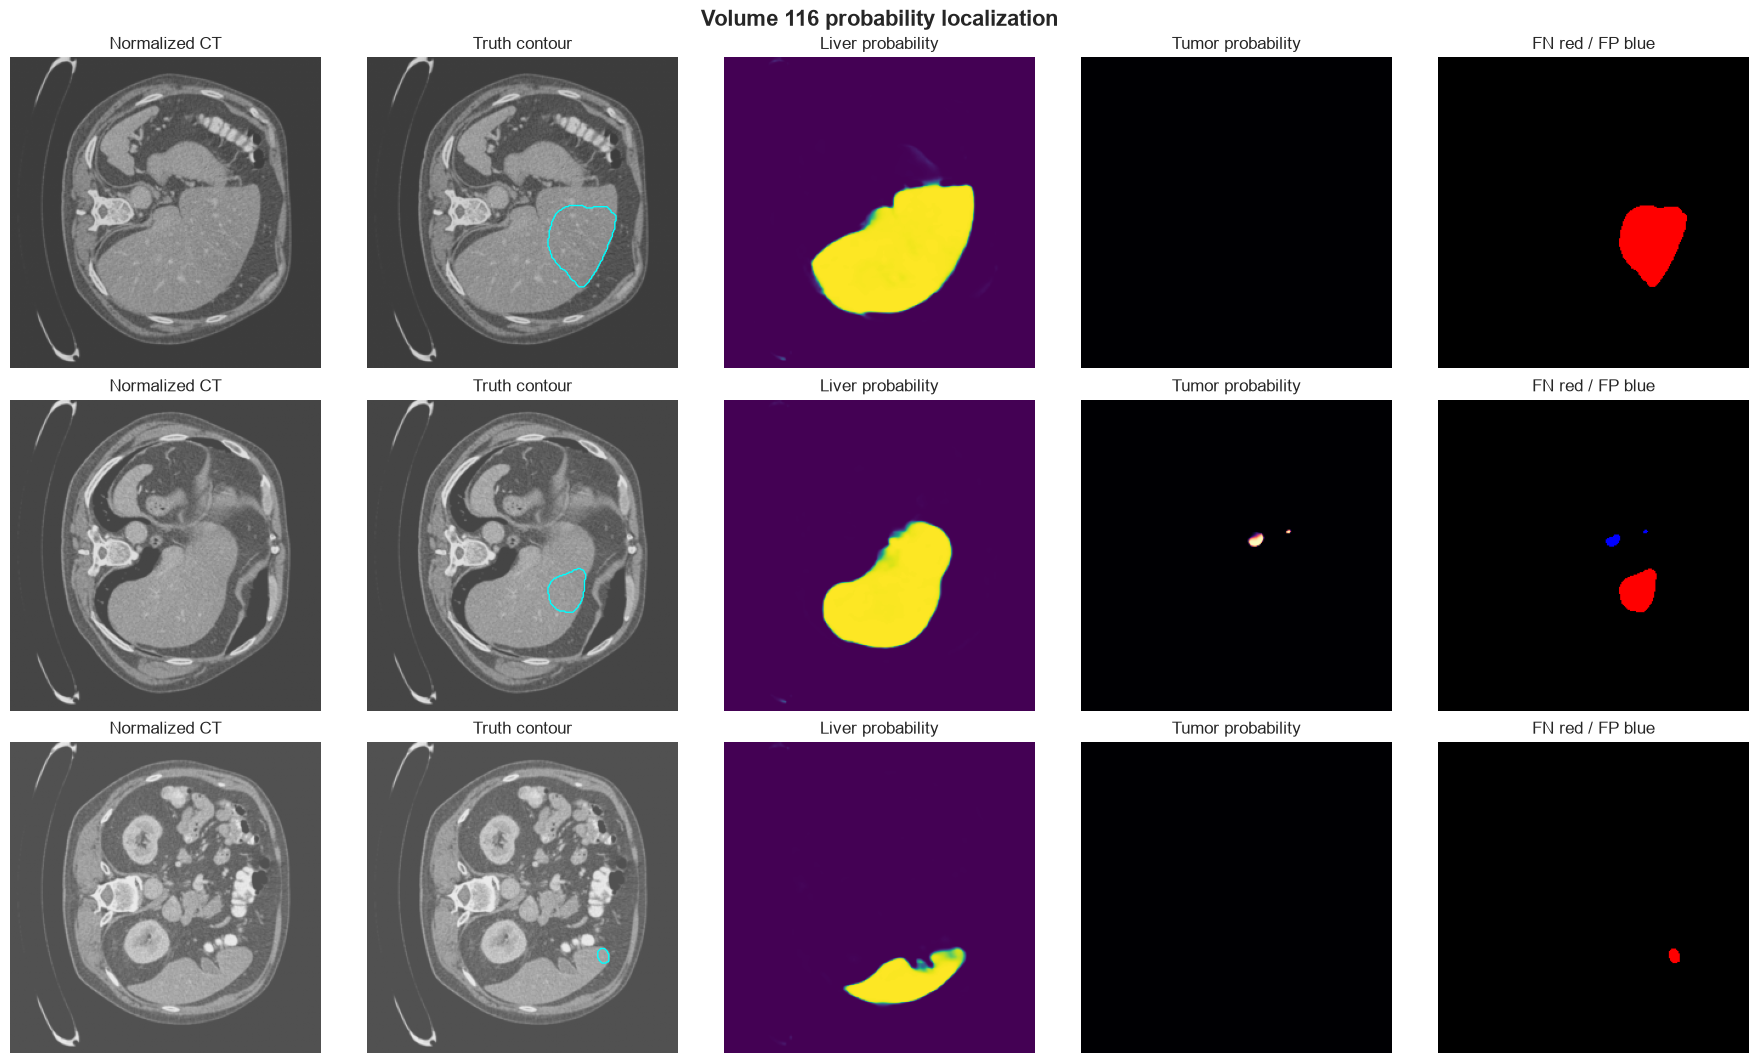

In [7]:
def probability_statistics(cached):
    rows = []
    for volume_id, item in cached.items():
        for index, sample_id in enumerate(item["sample_id"]):
            truth = item["tumor_truth"][index].astype(bool)
            organ = item["organ_truth"][index].astype(bool)
            probability = item["tumor_probability"][index].astype(np.float32)
            true_values = probability[truth]
            liver_background = probability[organ & ~truth]
            extra_liver = probability[~organ]
            rows.append({
                "sample_id": str(sample_id),
                "volume_id": volume_id,
                "slice_index": int(item["slice_index"][index]),
                "true_pixels": int(truth.sum()),
                "max_tumor_probability": float(probability.max()),
                "mean_probability_inside_truth": (
                    float(true_values.mean()) if true_values.size else np.nan
                ),
                "max_probability_inside_truth": (
                    float(true_values.max()) if true_values.size else np.nan
                ),
                "mean_liver_background_probability": (
                    float(liver_background.mean()) if liver_background.size else np.nan
                ),
                "mean_extra_liver_probability": (
                    float(extra_liver.mean()) if extra_liver.size else np.nan
                ),
            })
    return pd.DataFrame(rows)

def localization_panel(volume_id, statistics):
    item = probability_cache[volume_id]
    candidates = statistics.loc[
        statistics["volume_id"].eq(volume_id) & statistics["true_pixels"].gt(0)
    ].copy()
    selected = [
        candidates["true_pixels"].idxmax(),
        (candidates["true_pixels"] - candidates["true_pixels"].median()).abs().idxmin(),
        candidates["true_pixels"].idxmin(),
        candidates["mean_probability_inside_truth"].idxmax(),
        candidates["mean_probability_inside_truth"].idxmin(),
    ]
    selected = list(dict.fromkeys(selected))
    figure, axes = plt.subplots(len(selected), 5, figsize=(18, 3.6 * len(selected)))
    if len(selected) == 1:
        axes = axes[None, :]
    for row_axes, row_index in zip(axes, selected):
        row = statistics.loc[row_index]
        index = int(np.where(item["slice_index"] == row["slice_index"])[0][0])
        manifest_row = validation_manifest.loc[
            validation_manifest["sample_id"].eq(row["sample_id"])
        ].iloc[0]
        with Image.open(DATASET_ROOT / manifest_row["image_path"]) as handle:
            image = image_robust_normalize(
                np.asarray(handle.convert("L"), dtype=np.float32) / 255.0
            )
        truth = item["tumor_truth"][index].astype(bool)
        liver_probability = item["liver_probability"][index].astype(np.float32)
        tumor_probability = item["tumor_probability"][index].astype(np.float32)
        prediction = tumor_probability >= 0.50
        error = np.zeros((*truth.shape, 3), dtype=np.float32)
        error[truth & ~prediction, 0] = 1.0
        error[prediction & ~truth, 2] = 1.0
        panels = [
            (image, "Normalized CT", "gray", None),
            (image, "Truth contour", "gray", truth),
            (liver_probability, "Liver probability", "viridis", None),
            (tumor_probability, "Tumor probability", "magma", None),
            (error, "FN red / FP blue", None, None),
        ]
        for axis, (panel, title, cmap, contour) in zip(row_axes, panels):
            if panel.ndim == 2:
                axis.imshow(panel, cmap=cmap, vmin=0, vmax=1)
            else:
                axis.imshow(panel)
            if contour is not None and contour.any():
                axis.contour(contour, levels=[0.5], colors=["#00FFFF"], linewidths=1)
            axis.set_title(title)
            axis.axis("off")
        row_axes[0].set_ylabel(
            f"{row['sample_id']}\ntrue={row['true_pixels']:,}\n"
            f"pmax={row['max_tumor_probability']:.3f}",
            fontsize=8,
        )
    figure.suptitle(f"Volume {volume_id} probability localization", fontsize=16, weight="bold")
    figure.tight_layout()
    path = OUTPUT_DIR / f"probability_localization_{volume_id}.png"
    figure.savefig(path, dpi=170, bbox_inches="tight")
    plt.show()

slice_statistics = None
if RUN_FULL_DIAGNOSTIC:
    slice_statistics = probability_statistics(probability_cache)
    slice_statistics.to_csv(
        OUTPUT_DIR / "probability_slice_statistics.csv", index=False
    )
    for focus_volume in (104, 116):
        localization_panel(focus_volume, slice_statistics)
else:
    print("SKIP: localization analysis awaits probability cache.")

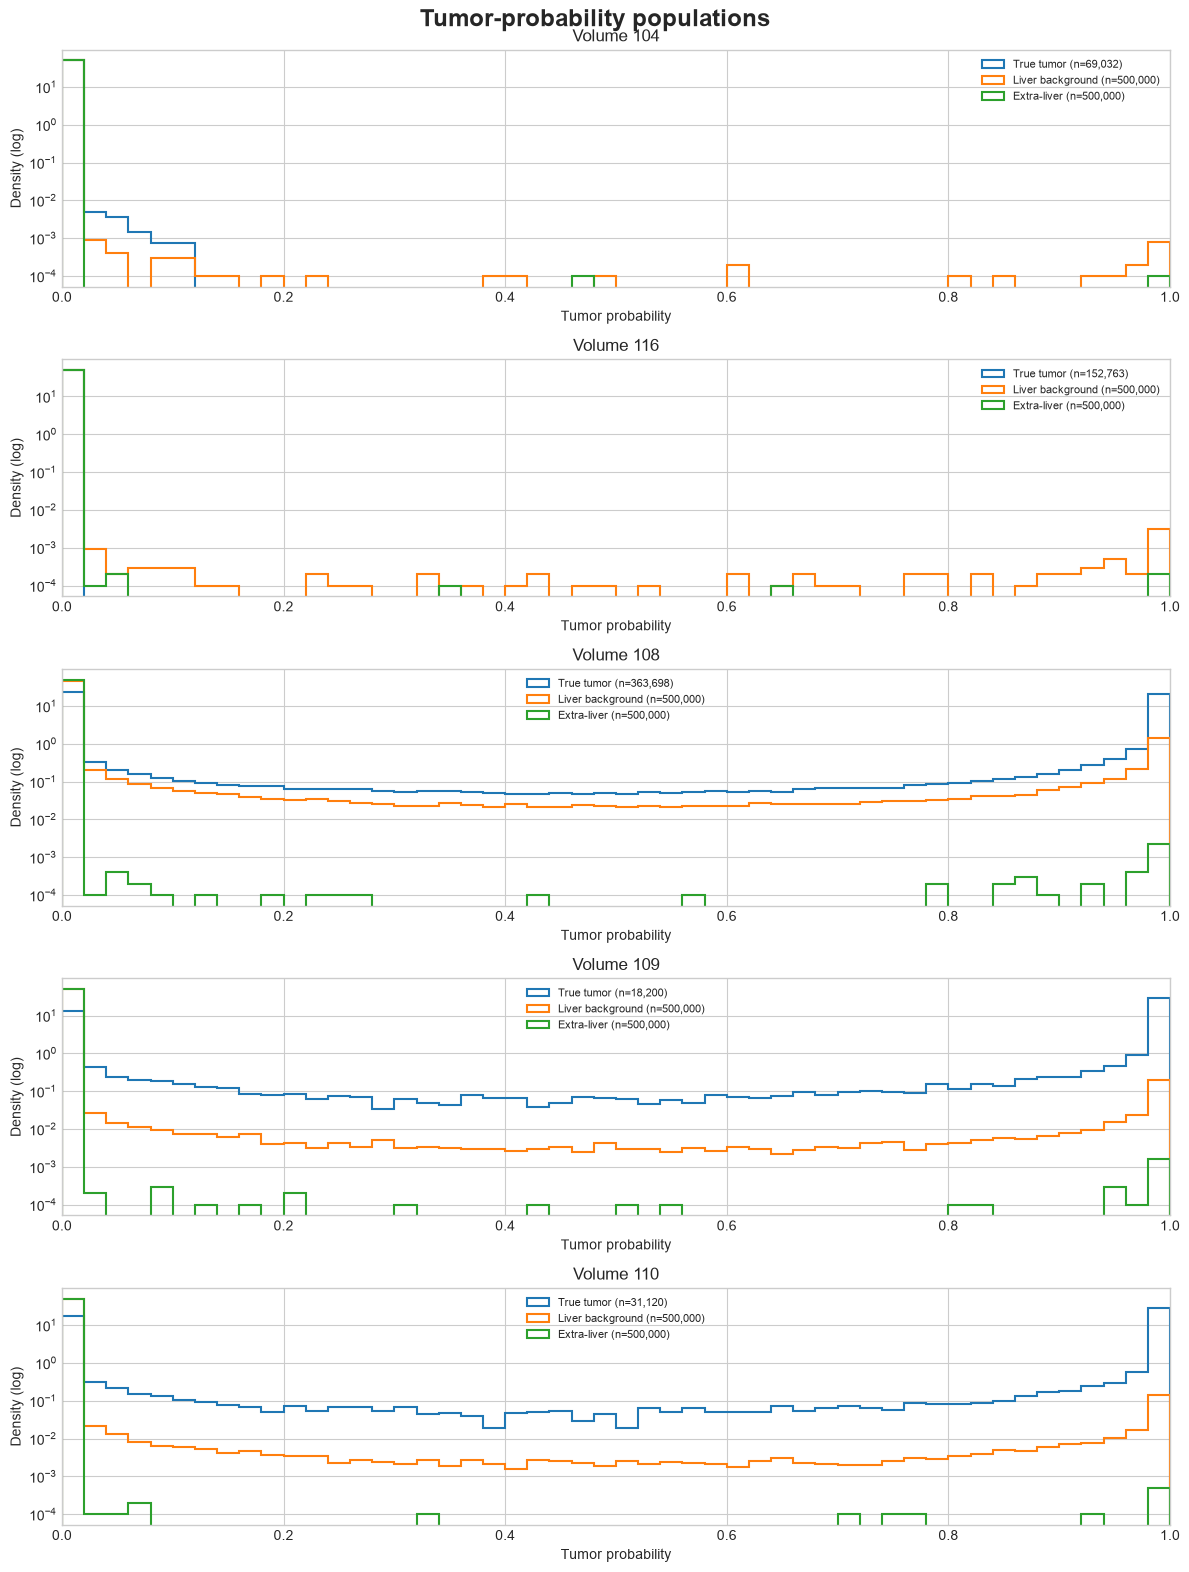

In [8]:
def plot_probability_populations():
    focus_volumes = [104, 116, 108, 109, 110]
    bins = np.linspace(0, 1, 51)
    figure, axes = plt.subplots(len(focus_volumes), 1, figsize=(12, 3.2 * len(focus_volumes)))
    rng = np.random.default_rng(SEED)
    for axis, volume_id in zip(axes, focus_volumes):
        item = probability_cache[volume_id]
        probability = item["tumor_probability"].astype(np.float32)
        truth = item["tumor_truth"].astype(bool)
        organ = item["organ_truth"].astype(bool)
        populations = {
            "True tumor": probability[truth],
            "Liver background": probability[organ & ~truth],
            "Extra-liver": probability[~organ],
        }
        for label, values in populations.items():
            if values.size > 500_000:
                values = rng.choice(values, 500_000, replace=False)
            axis.hist(values, bins=bins, density=True, histtype="step",
                      linewidth=1.5, label=f"{label} (n={len(values):,})")
        axis.set_yscale("log")
        axis.set_xlim(0, 1)
        axis.set_title(f"Volume {volume_id}")
        axis.set_xlabel("Tumor probability")
        axis.set_ylabel("Density (log)")
        axis.legend(fontsize=8)
    figure.suptitle("Tumor-probability populations", fontsize=17, weight="bold")
    figure.tight_layout()
    figure.savefig(
        OUTPUT_DIR / "probability_population_histograms.png",
        dpi=170, bbox_inches="tight",
    )
    plt.show()

if RUN_FULL_DIAGNOSTIC:
    plot_probability_populations()
else:
    print("SKIP: probability histograms await probability cache.")

In [9]:
def robust_effect_size(tumor_values, liver_values):
    tumor_mad = np.median(np.abs(tumor_values - np.median(tumor_values)))
    liver_mad = np.median(np.abs(liver_values - np.median(liver_values)))
    pooled = max(1.4826 * np.sqrt((tumor_mad ** 2 + liver_mad ** 2) / 2), 1e-6)
    return float((np.median(tumor_values) - np.median(liver_values)) / pooled)

def compute_hu_contrast():
    import nibabel as nib

    rows = []
    positive_rows = validation_manifest.loc[
        validation_manifest["tumor_pixels"].gt(0)
    ]
    for volume_id, group in positive_rows.groupby("volume_id", sort=True):
        first = group.iloc[0]
        ct_image = nib.load(str(first["source_volume_path"]))
        segmentation = nib.load(str(first["source_segmentation_path"]))
        transform = str(first["transform_applied"])
        for row in group.sort_values("slice_index").itertuples(index=False):
            slice_index = int(row.slice_index)
            hu = np.asanyarray(ct_image.dataobj[:, :, slice_index]).astype(np.float32)
            labels = np.asanyarray(
                segmentation.dataobj[:, :, slice_index]
            ).astype(np.uint8)
            if transform == "rot180":
                labels = np.rot90(labels, 2).copy()
            elif transform != "identity":
                raise ValueError(f"Unsupported transform: {transform}")
            tumor_values = hu[labels == 2]
            liver_values = hu[labels == 1]
            if not tumor_values.size or not liver_values.size:
                continue
            rows.append({
                "sample_id": row.sample_id,
                "volume_id": int(volume_id),
                "slice_index": slice_index,
                "tumor_pixels_native": int(tumor_values.size),
                "liver_background_pixels_native": int(liver_values.size),
                "tumor_mean_hu": float(tumor_values.mean()),
                "tumor_median_hu": float(np.median(tumor_values)),
                "liver_background_mean_hu": float(liver_values.mean()),
                "liver_background_median_hu": float(np.median(liver_values)),
                "mean_contrast_hu": float(tumor_values.mean() - liver_values.mean()),
                "median_contrast_hu": float(
                    np.median(tumor_values) - np.median(liver_values)
                ),
                "robust_effect_size": robust_effect_size(tumor_values, liver_values),
            })
    return pd.DataFrame(rows)

hu_slice = None
hu_volume = None
if RUN_FULL_DIAGNOSTIC and RUN_HU_ANALYSIS:
    hu_slice = compute_hu_contrast()
    assert not hu_slice.empty
    hu_slice.to_csv(OUTPUT_DIR / "hu_contrast_per_slice.csv", index=False)
    hu_volume = (
        hu_slice.groupby("volume_id")
        .agg(
            positive_slices=("sample_id", "size"),
            median_contrast_hu=("median_contrast_hu", "median"),
            mean_contrast_hu=("mean_contrast_hu", "mean"),
            median_effect_size=("robust_effect_size", "median"),
        )
        .reset_index()
    )
    hu_volume.to_csv(OUTPUT_DIR / "hu_contrast_per_volume.csv", index=False)
    display(hu_volume)
else:
    print("SKIP: source-HU analysis disabled or awaiting full diagnostic mode.")

,volume_id,positive_slices,median_contrast_hu,mean_contrast_hu,median_effect_size
0,104,122,-89.5,-76.957218,-4.122858
1,107,71,-25.5,-22.661905,-1.082776
2,108,202,-44.0,-36.663048,-1.773188
3,109,131,-64.0,-49.882406,-2.457697
4,110,130,-34.0,-35.158978,-1.239959
5,111,92,-51.5,-52.125222,-1.774655
6,112,26,-94.0,-85.936717,-3.971641
7,113,135,-38.0,-38.439407,-1.704925
8,116,133,-10.0,-10.569320,-0.346739


In [10]:
def dilated_support(probability, threshold, kernel):
    binary = torch.from_numpy((probability >= threshold).astype(np.float32))[:, None]
    if kernel > 1:
        binary = F.max_pool2d(binary, kernel_size=kernel, stride=1, padding=kernel // 2)
    return binary[:, 0].numpy() > 0

def evaluate_configuration(tumor_threshold, liver_threshold=None, kernel=1):
    patient_rows = []
    slice_rows = []
    total_intersection = total_predicted = total_true = 0
    positive_empty = positive_count = empty_fp = empty_count = 0
    removed_pixels = removed_true = removed_false = 0

    for volume_id, item in probability_cache.items():
        truth = item["tumor_truth"].astype(bool)
        raw = item["tumor_probability"].astype(np.float32) >= tumor_threshold
        if liver_threshold is None:
            prediction = raw
        else:
            support = dilated_support(
                item["liver_probability"].astype(np.float32),
                liver_threshold, kernel,
            )
            prediction = raw & support
            removed = raw & ~prediction
            removed_pixels += int(removed.sum())
            removed_true += int((removed & truth).sum())
            removed_false += int((removed & ~truth).sum())

        intersection = prediction & truth
        predicted_pixels = prediction.sum(axis=(1, 2))
        true_pixels = truth.sum(axis=(1, 2))
        intersections = intersection.sum(axis=(1, 2))
        total_intersection += int(intersections.sum())
        total_predicted += int(predicted_pixels.sum())
        total_true += int(true_pixels.sum())

        positive = true_pixels > 0
        empty = ~positive
        positive_count += int(positive.sum())
        positive_empty += int((positive & (predicted_pixels == 0)).sum())
        empty_count += int(empty.sum())
        empty_fp += int((empty & (predicted_pixels > 0)).sum())

        patient_rows.append({
            "volume_id": volume_id,
            "true_pixels": int(true_pixels.sum()),
            "predicted_pixels": int(predicted_pixels.sum()),
            "intersection_pixels": int(intersections.sum()),
            "micro_dice": float(
                (2 * intersections.sum() + 1e-6)
                / (predicted_pixels.sum() + true_pixels.sum() + 1e-6)
            ),
        })
        for index in range(len(true_pixels)):
            slice_rows.append({
                "sample_id": str(item["sample_id"][index]),
                "volume_id": volume_id,
                "true_pixels": int(true_pixels[index]),
                "predicted_pixels": int(predicted_pixels[index]),
                "intersection_pixels": int(intersections[index]),
            })

    patients = pd.DataFrame(patient_rows)
    slices = pd.DataFrame(slice_rows)
    positive_patients = patients.loc[patients["true_pixels"].gt(0)]
    positive_slices = slices.loc[slices["true_pixels"].gt(0)].copy()
    positive_slices["size_quartile"] = pd.qcut(
        positive_slices["true_pixels"], 4, labels=["Q1", "Q2", "Q3", "Q4"]
    )
    q1 = positive_slices.loc[positive_slices["size_quartile"].eq("Q1")]
    result = {
        "tumor_threshold": float(tumor_threshold),
        "liver_threshold": (
            float(liver_threshold) if liver_threshold is not None else np.nan
        ),
        "dilation_kernel": int(kernel),
        "mode": "raw" if liver_threshold is None else "liver_supported",
        "global_dice": (2 * total_intersection + 1e-6)
        / (total_predicted + total_true + 1e-6),
        "pixel_precision": total_intersection / max(total_predicted, 1),
        "pixel_recall": total_intersection / max(total_true, 1),
        "mean_patient_dice": float(positive_patients["micro_dice"].mean()),
        "median_patient_dice": float(positive_patients["micro_dice"].median()),
        "worst_positive_patient_dice": float(positive_patients["micro_dice"].min()),
        "volume_104_dice": float(
            patients.set_index("volume_id")["micro_dice"].get(104, np.nan)
        ),
        "volume_116_dice": float(
            patients.set_index("volume_id")["micro_dice"].get(116, np.nan)
        ),
        "q1_detected_pct": 100 * float((q1["intersection_pixels"] > 0).mean()),
        "positive_predicted_empty_pct": 100 * positive_empty / max(positive_count, 1),
        "empty_slice_false_positive_pct": 100 * empty_fp / max(empty_count, 1),
        "predicted_tumor_pixels": total_predicted,
        "pixels_removed_by_liver_support": removed_pixels,
        "true_pixels_removed_by_liver_support": removed_true,
        "false_pixels_removed_by_liver_support": removed_false,
    }
    return result, patients

configuration_results = None
patient_configuration_rows = []
if RUN_FULL_DIAGNOSTIC:
    result_rows = []
    for tumor_threshold in COARSE_TUMOR_THRESHOLDS:
        result, patients = evaluate_configuration(float(tumor_threshold))
        result_rows.append(result)
        patients = patients.assign(
            tumor_threshold=float(tumor_threshold),
            liver_threshold=np.nan,
            dilation_kernel=1,
            mode="raw",
        )
        patient_configuration_rows.append(patients)
        for liver_threshold in LIVER_THRESHOLDS:
            for kernel in LIVER_DILATION_KERNELS:
                result, patients = evaluate_configuration(
                    float(tumor_threshold), float(liver_threshold), kernel
                )
                result_rows.append(result)
                patient_configuration_rows.append(
                    patients.assign(
                        tumor_threshold=float(tumor_threshold),
                        liver_threshold=float(liver_threshold),
                        dilation_kernel=kernel,
                        mode="liver_supported",
                    )
                )
    configuration_results = pd.DataFrame(result_rows)
    patient_configuration_results = pd.concat(
        patient_configuration_rows, ignore_index=True
    )
    configuration_results.to_csv(
        OUTPUT_DIR / "calibration_configuration_results.csv", index=False
    )
    patient_configuration_results.to_csv(
        OUTPUT_DIR / "calibration_patient_metrics.csv", index=False
    )
    display(
        configuration_results.sort_values(
            ["mean_patient_dice", "empty_slice_false_positive_pct"],
            ascending=[False, True],
        ).head(15)
    )
else:
    print("SKIP: calibration sweep awaits probability cache.")

,tumor_threshold,liver_threshold,dilation_kernel,mode,global_dice,pixel_precision,pixel_recall,mean_patient_dice,median_patient_dice,worst_positive_patient_dice,volume_104_dice,volume_116_dice,q1_detected_pct,positive_predicted_empty_pct,empty_slice_false_positive_pct,predicted_tumor_pixels,pixels_removed_by_liver_support,true_pixels_removed_by_liver_support,false_pixels_removed_by_liver_support
208,0.7,NaN,1,raw,0.453658,0.727196,0.329656,0.332869,0.313549,6.526180e-12,1.443085e-11,6.526180e-12,27.376426,46.641075,3.194027,298962,0,0,0
209,0.7,0.3,1,liver_supported,0.453658,0.727196,0.329656,0.332869,0.313549,6.526180e-12,1.443085e-11,6.526180e-12,27.376426,46.641075,3.194027,298962,0,0,0
210,0.7,0.3,5,liver_supported,0.453658,0.727196,0.329656,0.332869,0.313549,6.526180e-12,1.443085e-11,6.526180e-12,27.376426,46.641075,3.194027,298962,0,0,0
211,0.7,0.3,11,liver_supported,0.453658,0.727196,0.329656,0.332869,0.313549,6.526180e-12,1.443085e-11,6.526180e-12,27.376426,46.641075,3.194027,298962,0,0,0
212,0.7,0.3,21,liver_supported,0.453658,0.727196,0.329656,0.332869,0.313549,6.526180e-12,1.443085e-11,6.526180e-12,27.376426,46.641075,3.194027,298962,0,0,0
213,0.7,0.3,31,liver_supported,0.453658,0.727196,0.329656,0.332869,0.313549,6.526180e-12,1.443085e-11,6.526180e-12,27.376426,46.641075,3.194027,298962,0,0,0
214,0.7,0.4,1,liver_supported,0.453658,0.727196,0.329656,0.332869,0.313549,6.526180e-12,1.443085e-11,6.526180e-12,27.376426,46.641075,3.194027,298962,0,0,0
215,0.7,0.4,5,liver_supported,0.453658,0.727196,0.329656,0.332869,0.313549,6.526180e-12,1.443085e-11,6.526180e-12,27.376426,46.641075,3.194027,298962,0,0,0
216,0.7,0.4,11,liver_supported,0.453658,0.727196,0.329656,0.332869,0.313549,6.526180e-12,1.443085e-11,6.526180e-12,27.376426,46.641075,3.194027,298962,0,0,0
217,0.7,0.4,21,liver_supported,0.453658,0.727196,0.329656,0.332869,0.313549,6.526180e-12,1.443085e-11,6.526180e-12,27.376426,46.641075,3.194027,298962,0,0,0


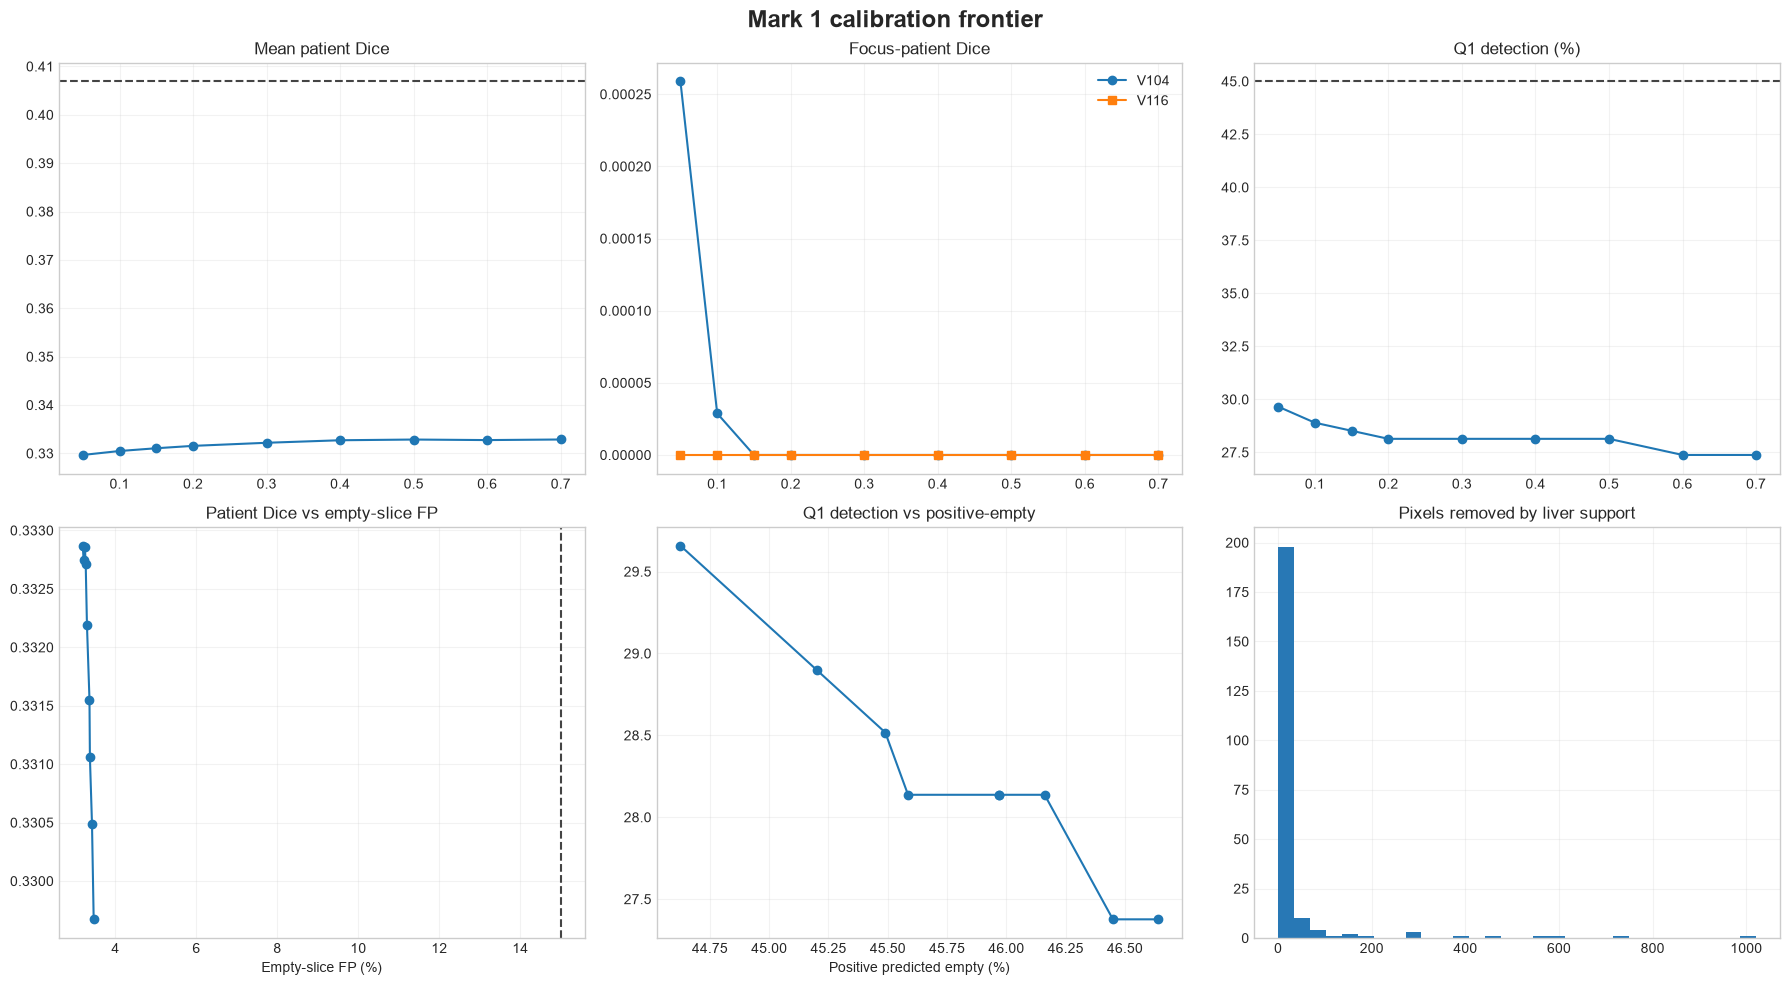

In [11]:
def gate_flags(frame):
    return (
        frame["mean_patient_dice"].ge(TARGETS["mean_patient_dice"])
        & frame["volume_104_dice"].ge(TARGETS["volume_104_dice"])
        & frame["volume_116_dice"].ge(TARGETS["volume_116_dice"])
        & frame["q1_detected_pct"].ge(TARGETS["q1_detected_pct"])
        & frame["positive_predicted_empty_pct"].le(
            TARGETS["positive_predicted_empty_pct"]
        )
        & frame["empty_slice_false_positive_pct"].le(
            TARGETS["empty_slice_false_positive_pct"]
        )
    )

selected_configuration = None
if RUN_FULL_DIAGNOSTIC:
    configuration_results["all_targets_passed"] = gate_flags(configuration_results)
    eligible = configuration_results.loc[
        configuration_results["all_targets_passed"]
    ].copy()
    if not eligible.empty:
        selected_configuration = eligible.sort_values(
            ["mean_patient_dice", "empty_slice_false_positive_pct"],
            ascending=[False, True],
        ).iloc[0]
    else:
        selected_configuration = configuration_results.sort_values(
            ["mean_patient_dice", "empty_slice_false_positive_pct"],
            ascending=[False, True],
        ).iloc[0]

    figure, axes = plt.subplots(2, 3, figsize=(18, 10))
    raw = configuration_results.loc[configuration_results["mode"].eq("raw")]
    axes[0, 0].plot(raw["tumor_threshold"], raw["mean_patient_dice"], marker="o")
    axes[0, 0].axhline(TARGETS["mean_patient_dice"], linestyle="--", color="#444")
    axes[0, 0].set_title("Mean patient Dice")
    axes[0, 1].plot(raw["tumor_threshold"], raw["volume_104_dice"], marker="o", label="V104")
    axes[0, 1].plot(raw["tumor_threshold"], raw["volume_116_dice"], marker="s", label="V116")
    axes[0, 1].set_title("Focus-patient Dice"); axes[0, 1].legend()
    axes[0, 2].plot(raw["tumor_threshold"], raw["q1_detected_pct"], marker="o")
    axes[0, 2].axhline(TARGETS["q1_detected_pct"], linestyle="--", color="#444")
    axes[0, 2].set_title("Q1 detection (%)")
    axes[1, 0].plot(
        raw["empty_slice_false_positive_pct"],
        raw["mean_patient_dice"], marker="o",
    )
    axes[1, 0].axvline(
        TARGETS["empty_slice_false_positive_pct"], linestyle="--", color="#444"
    )
    axes[1, 0].set_title("Patient Dice vs empty-slice FP")
    axes[1, 0].set_xlabel("Empty-slice FP (%)")
    axes[1, 1].plot(
        raw["positive_predicted_empty_pct"],
        raw["q1_detected_pct"], marker="o",
    )
    axes[1, 1].set_title("Q1 detection vs positive-empty")
    axes[1, 1].set_xlabel("Positive predicted empty (%)")
    removal = configuration_results.loc[
        configuration_results["mode"].eq("liver_supported")
    ]
    axes[1, 2].hist(
        removal["pixels_removed_by_liver_support"], bins=30, color="#2878B5"
    )
    axes[1, 2].set_title("Pixels removed by liver support")
    for axis in axes.flat:
        axis.grid(alpha=0.25)
    figure.suptitle("Mark 1 calibration frontier", fontsize=17, weight="bold")
    figure.tight_layout()
    figure.savefig(
        OUTPUT_DIR / "calibration_frontier_dashboard.png",
        dpi=170, bbox_inches="tight",
    )
    plt.show()
else:
    print("SKIP: acceptance gate awaits calibration results.")

In [12]:
bootstrap_intervals = None
if RUN_FULL_DIAGNOSTIC:
    selected_filter = (
        patient_configuration_results["mode"].eq(selected_configuration["mode"])
        & patient_configuration_results["tumor_threshold"].eq(
            selected_configuration["tumor_threshold"]
        )
        & patient_configuration_results["dilation_kernel"].eq(
            selected_configuration["dilation_kernel"]
        )
    )
    if selected_configuration["mode"] == "liver_supported":
        selected_filter &= patient_configuration_results["liver_threshold"].eq(
            selected_configuration["liver_threshold"]
        )
    selected_patients = patient_configuration_results.loc[selected_filter].copy()
    selected_positive = selected_patients.loc[
        selected_patients["true_pixels"].gt(0), "micro_dice"
    ].to_numpy()
    rng = np.random.default_rng(SEED)
    bootstrap_means = np.array([
        rng.choice(selected_positive, size=len(selected_positive), replace=True).mean()
        for _ in range(BOOTSTRAP_ITERATIONS)
    ])
    bootstrap_intervals = pd.DataFrame([{
        "configuration_mode": selected_configuration["mode"],
        "tumor_threshold": selected_configuration["tumor_threshold"],
        "liver_threshold": selected_configuration["liver_threshold"],
        "dilation_kernel": selected_configuration["dilation_kernel"],
        "patients": len(selected_positive),
        "bootstrap_iterations": BOOTSTRAP_ITERATIONS,
        "mean_dice_p2_5": np.percentile(bootstrap_means, 2.5),
        "mean_dice_p50": np.percentile(bootstrap_means, 50),
        "mean_dice_p97_5": np.percentile(bootstrap_means, 97.5),
        "original_median": np.median(selected_positive),
        "original_q25": np.percentile(selected_positive, 25),
        "original_q75": np.percentile(selected_positive, 75),
    }])
    bootstrap_intervals.to_csv(
        OUTPUT_DIR / "bootstrap_confidence_intervals.csv", index=False
    )
    display(bootstrap_intervals)
else:
    print("SKIP: bootstrap awaits selected configuration.")

,configuration_mode,tumor_threshold,liver_threshold,dilation_kernel,patients,bootstrap_iterations,mean_dice_p2_5,mean_dice_p50,mean_dice_p97_5,original_median,original_q25,original_q75
0,raw,0.7,NaN,1,9,1000,0.134014,0.336343,0.511702,0.313549,0.070361,0.595275


In [13]:
gate_result = None
if RUN_FULL_DIAGNOSTIC:
    calibration_passed = bool(
        configuration_results["all_targets_passed"].any()
    )
    selected = selected_configuration.to_dict()
    if calibration_passed:
        failure_category = "calibration_success"
        next_mark = "freeze_global_configuration"
    else:
        focus_stats = slice_statistics.loc[
            slice_statistics["volume_id"].isin([104, 116])
            & slice_statistics["true_pixels"].gt(0)
        ]
        localized_probability = float(
            focus_stats["max_probability_inside_truth"].median()
        )
        if localized_probability >= 0.10:
            failure_category = "weak_but_localized"
            next_mark = "stable_recall_objective_or_predicted_liver_normalization"
        elif hu_volume is not None and (
            hu_volume.loc[
                hu_volume["volume_id"].isin([104, 116]),
                "median_effect_size",
            ].abs().median() < 0.5
        ):
            failure_category = "low_source_contrast"
            next_mark = "controlled_multi_window_source_nifti_experiment"
        else:
            failure_category = "mislocalized_or_absent_signal"
            next_mark = "predicted_liver_roi_or_capacity_experiment"

    gate_result = {
        "status": "mark_1_diagnostic_complete",
        "calibration_gate_passed": calibration_passed,
        "failure_category": failure_category,
        "selected_global_configuration": selected if calibration_passed else None,
        "best_observed_configuration_for_diagnosis": selected,
        "manifest_sha256": manifest_hash,
        "checkpoint_sha256": checkpoint_hash,
        "parent_checkpoint_sha256": checkpoint["source_checkpoint_sha256"],
        "checkpoint_epoch": int(checkpoint["epoch"]),
        "test_images_accessed": False,
        "next_mark": next_mark,
        "manual_review_required": not calibration_passed,
    }
    (OUTPUT_DIR / "mark_1_gate_result.json").write_text(
        json.dumps(gate_result, indent=2), encoding="utf-8"
    )
    write_status(
        last_completed_step=10,
        cache_complete=True,
        configurations_evaluated=int(len(configuration_results)),
        next_resumable_action="review gate result and freeze Mark 2 decision",
    )
    display(pd.DataFrame([gate_result]).T.rename(columns={0: "value"}))
else:
    print(
        "PREFLIGHT COMPLETE. Set RUN_FULL_DIAGNOSTIC=True and rerun top-to-bottom "
        "to generate the evidence required for a Mark 1 decision."
    )

,value
status,mark_1_diagnostic_complete
calibration_gate_passed,False
failure_category,mislocalized_or_absent_signal
selected_global_configuration,None
best_observed_configuration_for_diagnosis,"{'tumor_threshold': 0.699999988079071, 'liver_..."
manifest_sha256,575a6fc391d63dc9bbbbb3317efe4d0f65edd57457ae63...
checkpoint_sha256,9c4160bbd68891f9dc4e5f04ceca4391f38c5869b3f81c...
parent_checkpoint_sha256,5f18223c0f618d45d1433dc4a48d950fdea8a039db9ea5...
checkpoint_epoch,8
test_images_accessed,False
